# Experimento de Drift Sintetico — Physionet (Sepsis)

Carga el dataset **physionet**, entrena un **XGBClassifier** y aplica drift sintetico
(**covariate**, **concept** y **both**) con distintas severidades sobre las variables
de signos vitales para evaluar la degradacion del rendimiento (AUC-ROC).

## Variables de drift

```
VITALS = ['HR', 'SBP', 'MAP', 'Resp', 'Temp']
```

## Flujo

1. Carga del dataset (train / id_test)
2. Entrenamiento XGBoost baseline sobre todas las features numericas
3. Evaluacion baseline (sin drift)
4. Ajuste del DriftInjector sobre VITALS
5. Sweep de severidad — **Covariate Drift**
6. Sweep de severidad — **Concept Drift** (label flipping)
7. Sweep de severidad — **Both** (covariate + concept)
8. Visualizacion de distribuciones (antes/despues con `plot_numeric_drift_grid`)
9. Distribucion de labels bajo concept drift
10. Tabla de metricas de drift (`DriftInjector.summary`)


## Formulario matematico

### Covariate Drift (Mixtura Beta)

$$x_{\\text{drift},i} = m_i \\cdot \\tilde{x}_i + (1 - m_i) \\cdot x_{\\text{orig},i}$$

Donde:

- $m_i \\sim \\text{Bernoulli}(\\gamma)$ — mascara de drift; $\\gamma$ es `drift_severity`.
- $\\tilde{x}_i \\sim \\text{Beta}(\\alpha_q, \\beta_q)$ — muestra de la distribucion Beta objetivo.
- $x_{\\text{orig},i}$ — valor original normalizado a $[0,1]$.

Vuelta a escala original: $X_{\\text{drift},i} = x_{\\text{drift},i}\\cdot(X_{\\max}-X_{\\min})+X_{\\min}$

### Concept Drift (Label Flipping)

$$Y_{\\text{drift},i} = \\begin{cases} 1 - Y_i & \\text{con probabilidad } p = 0.45\\cdot\\gamma \\\\ Y_i & \\text{con probabilidad } 1 - p \\end{cases}$$

Donde:

- $Y_i \\in \\{0,1\\}$ es el label original de Sepsis.
- El factor $0.45$ limita el flipping al 45% para no invertir completamente la senal predictiva.


## 1. Imports y configuracion


In [12]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    average_precision_score,
    classification_report,
    precision_recall_curve,
)
from xgboost import XGBClassifier

from darl.data.get_dataset import load_dataset, find_project_root
from darl.drift import DriftInjector
from darl.visualization.drift_plots import plot_numeric_drift_grid

SEED = 42
np.random.seed(SEED)

# Variables de signos vitales sobre las que se aplica el drift
VITALS = ["HR", "SBP", "MAP", "Resp", "Temp"]

# Configuracion de direccion de drift por variable
NUM_CFG = {
    "HR": "high",
    "SBP": "low",
    "MAP": "low",
    "Resp": "high",
    "Temp": "extreme",
}

LABEL_COL = "SepsisLabel"

print("Imports OK")
print(f"VITALS: {VITALS}")
print(f"Configuracion de drift: {NUM_CFG}")

Imports OK
VITALS: ['HR', 'SBP', 'MAP', 'Resp', 'Temp']
Configuracion de drift: {'HR': 'high', 'SBP': 'low', 'MAP': 'low', 'Resp': 'high', 'Temp': 'extreme'}


## 2. Carga del dataset Physionet


In [ ]:
PROJECT_ROOT = find_project_root()

dset = load_dataset("physionet")

X_train, y_train, _, _ = dset.get_pandas(split="train")
X_test, y_test, _, _ = dset.get_pandas(split="id_test")

# Construir DataFrames con label incluido
df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values

df_target = X_test.copy()
df_target[LABEL_COL] = y_test.values

print(f"Train  : {df_train.shape}")
print(f"Target : {df_target.shape}")
print(f"Prevalencia Sepsis Train : {y_train.mean():.4f}")
print(f"Prevalencia Sepsis Target: {y_test.mean():.4f}")
print()
print("Variables VITALS presentes:", [c for c in VITALS if c in df_target.columns])

## 3. Entrenamiento XGBoost Baseline

El modelo se entrena sobre **todas las features numericas** del dataset.
El drift se aplica solo sobre VITALS, pero el modelo usa todo el conjunto de features.


In [ ]:
NUMERIC_COLS = (
    df_train.drop(columns=[LABEL_COL])
    .select_dtypes(include=["number"])
    .columns.tolist()
)

X_tr = df_train[NUMERIC_COLS].values
y_tr = df_train[LABEL_COL].values

X_te = df_target[NUMERIC_COLS].values
y_te = df_target[LABEL_COL].values

print(f"Features de entrenamiento: {len(NUMERIC_COLS)}")

# Ratio de desbalance: penaliza mas los errores en la clase minoritaria (Sepsis)
# Usar np.count_nonzero evita depender del método .sum en arrays booleanos
neg = int(np.count_nonzero(y_tr == 0))
pos = int(np.count_nonzero(y_tr == 1))
SCALE_POS_WEIGHT = neg / pos if pos > 0 else 1.0
print(
    f"Clase 0: {neg:,}  |  Clase 1: {pos:,}  |  scale_pos_weight={SCALE_POS_WEIGHT:.1f}"
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT,  # corrige desbalance de clases
    eval_metric="logloss",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

model.fit(X_tr, y_tr)
print("Modelo entrenado.")

Features de entrenamiento: 39
Clase 0: 1,109,051  |  Clase 1: 13,248  |  scale_pos_weight=83.7
Modelo entrenado.


## 4. Evaluacion Baseline (sin drift)

Con desbalance severo (~1.2% positivos), el umbral por defecto de 0.5 hace
que el modelo casi nunca prediga Sepsis. Se busca el **umbral optimo** que
maximiza el F1-score sobre el conjunto de test, y se agrega **AUC-PR**
(Area bajo la curva Precision-Recall) como metrica complementaria.


In [15]:
y_prob_base = model.predict_proba(X_te)[:, 1]

# Convert y_te to numpy array to avoid type issues
y_te_array = np.asarray(y_te).ravel()

# AUC-ROC (independiente del umbral)
auc_base = roc_auc_score(y_te_array, y_prob_base)

# AUC-PR (mas informativo con desbalance)
aupr_base = average_precision_score(y_te_array, y_prob_base)

# Umbral optimo: maximiza F1 en test set
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_te_array, y_prob_base)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9)
best_idx = f1_arr.argmax()
BEST_THRESHOLD = float(thresh_arr[best_idx])

y_pred_base = (y_prob_base >= BEST_THRESHOLD).astype(int)
f1_base = f1_score(y_te_array, y_pred_base)

print(f"AUC-ROC baseline         : {auc_base:.4f}")
print(f"AUC-PR  baseline         : {aupr_base:.4f}")
print(f"Umbral optimo (F1)       : {BEST_THRESHOLD:.4f}")
print(f"F1-score (umbral optimo) : {f1_base:.4f}")
print()
print(classification_report(y_te_array, y_pred_base))

AUC-ROC baseline         : 0.7824
AUC-PR  baseline         : 0.0659
Umbral optimo (F1)       : 0.7563
F1-score (umbral optimo) : 0.1299

              precision    recall  f1-score   support

           0       0.99      0.98      0.98    138598
           1       0.09      0.21      0.13      1690

    accuracy                           0.97    140288
   macro avg       0.54      0.59      0.56    140288
weighted avg       0.98      0.97      0.97    140288



## 5. Ajuste del DriftInjector sobre VITALS

El `DriftInjector` aprende los parametros Beta de cada vital a partir de `df_train`.


In [16]:
inj = DriftInjector(random_state=SEED)
inj.fit(df_train, numeric_cols=VITALS)
print("DriftInjector entrenado en datos de referencia.")
print(f"Vitals ajustados: {inj._numeric_cols}")

DriftInjector entrenado en datos de referencia.
Vitals ajustados: ['HR', 'SBP', 'MAP', 'Resp', 'Temp']


## 6. Sweep de Severidad — Covariate Drift

Shift de distribucion Beta en las cinco variables VITALS.
Los labels no se modifican. Se espera que el AUC caiga al aumentar la severidad.


In [ ]:
SEVERITIES = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]

results_cov = []

for sev in SEVERITIES:
    if sev == 0.0:
        df_d = df_target.copy()
    else:
        df_d, meta_cov = inj.transform(
            df_target,
            drift_severity=sev,
            numeric_drift_config=NUM_CFG,
            drift_type="covariate",
        )

    X_d = df_d[NUMERIC_COLS].values
    y_d = df_d[LABEL_COL].values

    y_prob = model.predict_proba(X_d)[:, 1]
    y_pred = (y_prob >= BEST_THRESHOLD).astype(int)  # umbral optimo

    auc = roc_auc_score(y_d, y_prob)
    aupr = average_precision_score(y_d, y_prob)
    f1 = f1_score(y_d, y_pred)

    results_cov.append(
        {
            "severidad": sev,
            "drift_type": "covariate",
            "auc": round(auc, 4),
            "aupr": round(aupr, 4),
            "delta_auc": round(auc - auc_base, 4),
            "f1": round(f1, 4),
        }
    )
    print(
        f"  sev={sev:.1f} | AUC={auc:.4f} | AUPR={aupr:.4f} | DAUC={auc - auc_base:+.4f} | F1={f1:.4f}"
    )

df_results_cov = pd.DataFrame(results_cov)
display(df_results_cov)

  sev=0.0 | AUC=0.7824 | AUPR=0.0659 | DAUC=+0.0000 | F1=0.1299
  sev=0.1 | AUC=0.7675 | AUPR=0.0560 | DAUC=-0.0149 | F1=0.1126
  sev=0.2 | AUC=0.7531 | AUPR=0.0485 | DAUC=-0.0293 | F1=0.0977
  sev=0.3 | AUC=0.7322 | AUPR=0.0452 | DAUC=-0.0502 | F1=0.0877
  sev=0.5 | AUC=0.7037 | AUPR=0.0352 | DAUC=-0.0787 | F1=0.0660
  sev=0.7 | AUC=0.6795 | AUPR=0.0293 | DAUC=-0.1029 | F1=0.0586


,severidad,drift_type,auc,aupr,delta_auc,f1
0,0.0,covariate,0.7824,0.0659,0.0000,0.1299
1,0.1,covariate,0.7675,0.0560,-0.0149,0.1126
2,0.2,covariate,0.7531,0.0485,-0.0293,0.0977
3,0.3,covariate,0.7322,0.0452,-0.0502,0.0877
4,0.5,covariate,0.7037,0.0352,-0.0787,0.0660
5,0.7,covariate,0.6795,0.0293,-0.1029,0.0586


## 7. Sweep de Severidad — Concept Drift (Label Flipping)

Se aplica label flipping con probabilidad $p = 0.45 \\cdot \\gamma$.
Las features no se modifican. El AUC converge hacia 0.5 al aumentar la severidad.


In [18]:
results_con = []

for sev in SEVERITIES:
    if sev == 0.0:
        df_d = df_target.copy()
    else:
        df_d, meta_con = inj.transform(
            df_target,
            drift_severity=sev,
            label_col=LABEL_COL,
            drift_type="concept",
        )

    X_d = df_d[NUMERIC_COLS].values
    y_d = df_d[LABEL_COL].values

    y_prob = model.predict_proba(X_d)[:, 1]
    y_pred = (y_prob >= BEST_THRESHOLD).astype(int)  # umbral optimo

    auc = roc_auc_score(y_d, y_prob)
    aupr = average_precision_score(y_d, y_prob)
    f1 = f1_score(y_d, y_pred)

    results_con.append(
        {
            "severidad": sev,
            "drift_type": "concept",
            "auc": round(auc, 4),
            "aupr": round(aupr, 4),
            "delta_auc": round(auc - auc_base, 4),
            "f1": round(f1, 4),
        }
    )
    print(
        f"  sev={sev:.1f} | AUC={auc:.4f} | AUPR={aupr:.4f} | DAUC={auc - auc_base:+.4f} | F1={f1:.4f}"
    )

df_results_con = pd.DataFrame(results_con)
display(df_results_con)

  sev=0.0 | AUC=0.7824 | AUPR=0.0659 | DAUC=+0.0000 | F1=0.1299
  sev=0.1 | AUC=0.5549 | AUPR=0.0766 | DAUC=-0.2275 | F1=0.0825
  sev=0.2 | AUC=0.5256 | AUPR=0.1148 | DAUC=-0.2568 | F1=0.0711
  sev=0.3 | AUC=0.5203 | AUPR=0.1581 | DAUC=-0.2621 | F1=0.0636
  sev=0.5 | AUC=0.5133 | AUPR=0.2443 | DAUC=-0.2691 | F1=0.0588
  sev=0.7 | AUC=0.5052 | AUPR=0.3264 | DAUC=-0.2773 | F1=0.0562


,severidad,drift_type,auc,aupr,delta_auc,f1
0,0.0,concept,0.7824,0.0659,0.0000,0.1299
1,0.1,concept,0.5549,0.0766,-0.2275,0.0825
2,0.2,concept,0.5256,0.1148,-0.2568,0.0711
3,0.3,concept,0.5203,0.1581,-0.2621,0.0636
4,0.5,concept,0.5133,0.2443,-0.2691,0.0588
5,0.7,concept,0.5052,0.3264,-0.2773,0.0562


## 8. Sweep de Severidad — Both (Covariate + Concept)

Combina shift de VITALS **y** label flipping. Escenario mas severo.


In [19]:
results_both = []

for sev in SEVERITIES:
    if sev == 0.0:
        df_d = df_target.copy()
    else:
        df_d, meta_both = inj.transform(
            df_target,
            drift_severity=sev,
            numeric_drift_config=NUM_CFG,
            label_col=LABEL_COL,
            drift_type="both",
        )

    X_d = df_d[NUMERIC_COLS].values
    y_d = df_d[LABEL_COL].values

    y_prob = model.predict_proba(X_d)[:, 1]
    y_pred = (y_prob >= BEST_THRESHOLD).astype(int)  # umbral optimo

    auc = roc_auc_score(y_d, y_prob)
    aupr = average_precision_score(y_d, y_prob)
    f1 = f1_score(y_d, y_pred)

    results_both.append(
        {
            "severidad": sev,
            "drift_type": "both",
            "auc": round(auc, 4),
            "aupr": round(aupr, 4),
            "delta_auc": round(auc - auc_base, 4),
            "f1": round(f1, 4),
        }
    )
    print(
        f"  sev={sev:.1f} | AUC={auc:.4f} | AUPR={aupr:.4f} | DAUC={auc - auc_base:+.4f} | F1={f1:.4f}"
    )

df_results_both = pd.DataFrame(results_both)
display(df_results_both)

  sev=0.0 | AUC=0.7824 | AUPR=0.0659 | DAUC=+0.0000 | F1=0.1299
  sev=0.1 | AUC=0.5546 | AUPR=0.0767 | DAUC=-0.2279 | F1=0.0835
  sev=0.2 | AUC=0.5267 | AUPR=0.1159 | DAUC=-0.2558 | F1=0.0866
  sev=0.3 | AUC=0.5137 | AUPR=0.1528 | DAUC=-0.2687 | F1=0.0853
  sev=0.5 | AUC=0.5099 | AUPR=0.2377 | DAUC=-0.2725 | F1=0.1065
  sev=0.7 | AUC=0.5042 | AUPR=0.3232 | DAUC=-0.2782 | F1=0.1298


,severidad,drift_type,auc,aupr,delta_auc,f1
0,0.0,both,0.7824,0.0659,0.0000,0.1299
1,0.1,both,0.5546,0.0767,-0.2279,0.0835
2,0.2,both,0.5267,0.1159,-0.2558,0.0866
3,0.3,both,0.5137,0.1528,-0.2687,0.0853
4,0.5,both,0.5099,0.2377,-0.2725,0.1065
5,0.7,both,0.5042,0.3232,-0.2782,0.1298


## 9. Curvas de degradacion AUC vs Severidad


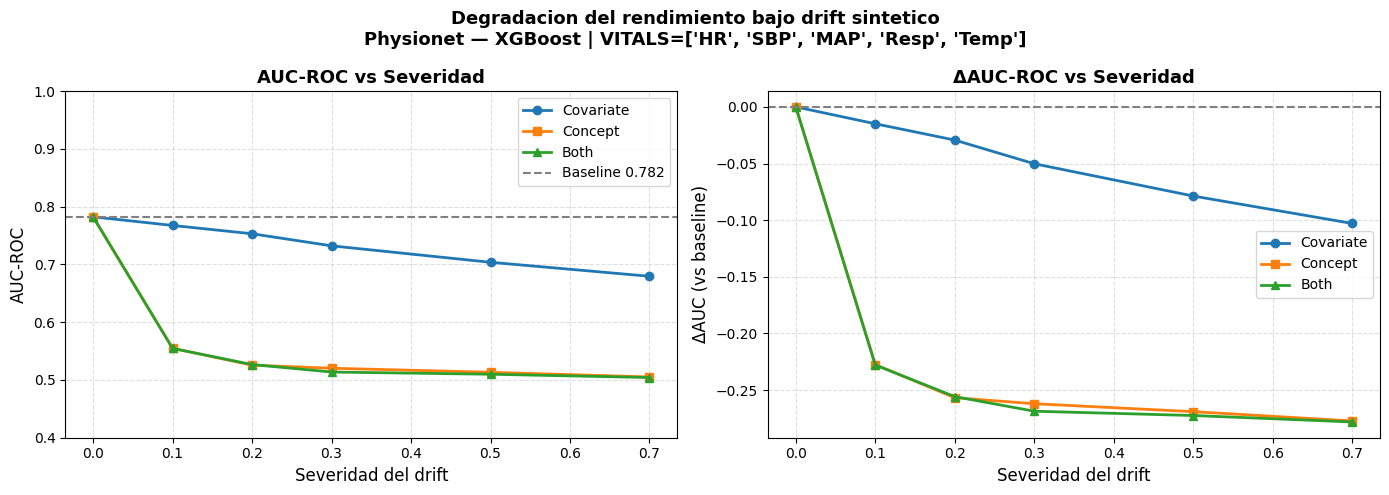

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC absoluto
ax = axes[0]
ax.plot(
    df_results_cov["severidad"],
    df_results_cov["auc"],
    "o-",
    label="Covariate",
    color="#1f77b4",
    lw=2,
)
ax.plot(
    df_results_con["severidad"],
    df_results_con["auc"],
    "s-",
    label="Concept",
    color="#ff7f0e",
    lw=2,
)
ax.plot(
    df_results_both["severidad"],
    df_results_both["auc"],
    "^-",
    label="Both",
    color="#2ca02c",
    lw=2,
)
ax.axhline(
    auc_base, color="gray", linestyle="--", lw=1.5, label=f"Baseline {auc_base:.3f}"
)
ax.set_xlabel("Severidad del drift", fontsize=12)
ax.set_ylabel("AUC-ROC", fontsize=12)
ax.set_title("AUC-ROC vs Severidad", fontweight="bold", fontsize=13)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0.4, 1.0)

# Delta AUC
ax = axes[1]
ax.plot(
    df_results_cov["severidad"],
    df_results_cov["delta_auc"],
    "o-",
    label="Covariate",
    color="#1f77b4",
    lw=2,
)
ax.plot(
    df_results_con["severidad"],
    df_results_con["delta_auc"],
    "s-",
    label="Concept",
    color="#ff7f0e",
    lw=2,
)
ax.plot(
    df_results_both["severidad"],
    df_results_both["delta_auc"],
    "^-",
    label="Both",
    color="#2ca02c",
    lw=2,
)
ax.axhline(0, color="gray", linestyle="--", lw=1.5)
ax.set_xlabel("Severidad del drift", fontsize=12)
ax.set_ylabel("ΔAUC (vs baseline)", fontsize=12)
ax.set_title("ΔAUC-ROC vs Severidad", fontweight="bold", fontsize=13)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    "Degradacion del rendimiento bajo drift sintetico\n"
    f"Physionet — XGBoost | VITALS={VITALS}",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 10. Distribucion antes/despues — Covariate Drift (severidad=0.3)

Replica la visualizacion del `drift_demo.ipynb`.


Resumen de drift en covariables:


,type,drift_severity,direction,beta_orig,beta_target,ks_stat,ks_pval,psi
variable,,,,,,,,
HR,numeric,0.3,high,"(10.24, 31.14)","(5.00, 2.00)",0.282913,0.0,0.512599
SBP,numeric,0.3,low,"(12.45, 20.75)","(2.00, 5.00)",0.137228,0.0,0.424287
MAP,numeric,0.3,low,"(11.39, 39.83)","(2.00, 5.00)",0.098569,0.0,0.296130
Resp,numeric,0.3,high,"(9.39, 43.39)","(5.00, 2.00)",0.291043,0.0,2.249927
Temp,numeric,0.3,extreme,"(189.44, 153.77)","(0.50, 0.50)",0.145887,0.0,0.513385


Prevalencia de Sepsis original  : 0.0120
Prevalencia de Sepsis post-drift: 0.0120


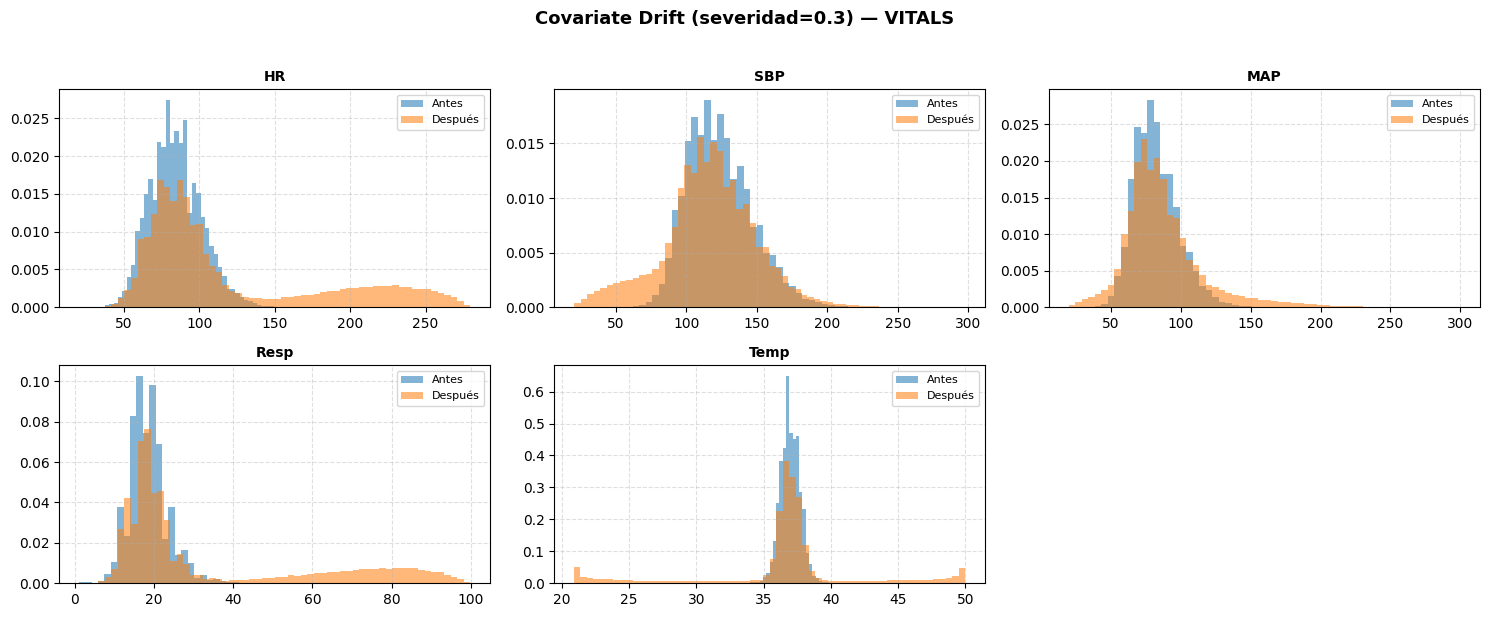

In [21]:
df_cov, meta_cov = inj.transform(
    df_target,
    drift_severity=0.3,
    numeric_drift_config=NUM_CFG,
)

print("Resumen de drift en covariables:")
display(DriftInjector.summary(meta_cov))

print(f"Prevalencia de Sepsis original  : {df_target[LABEL_COL].mean():.4f}")
print(f"Prevalencia de Sepsis post-drift: {df_cov[LABEL_COL].mean():.4f}")

fig_cov = plot_numeric_drift_grid(df_target, df_cov, cols=VITALS, ncols=3, bins=60)
plt.suptitle(
    "Covariate Drift (severidad=0.3) — VITALS", fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

## 11. Distribucion de labels bajo Concept Drift

Con $p_{\\text{flip}} = 0.45 \\cdot \\gamma$, la prevalencia $P(Y=1)$ converge
hacia 0.5 al aumentar la severidad.


,severidad,p_flip,prevalencia_Y1
0,0.0,0.000,0.0120
1,0.1,0.045,0.0554
2,0.2,0.090,0.0979
3,0.3,0.135,0.1448
4,0.5,0.225,0.2313
5,0.7,0.315,0.3179


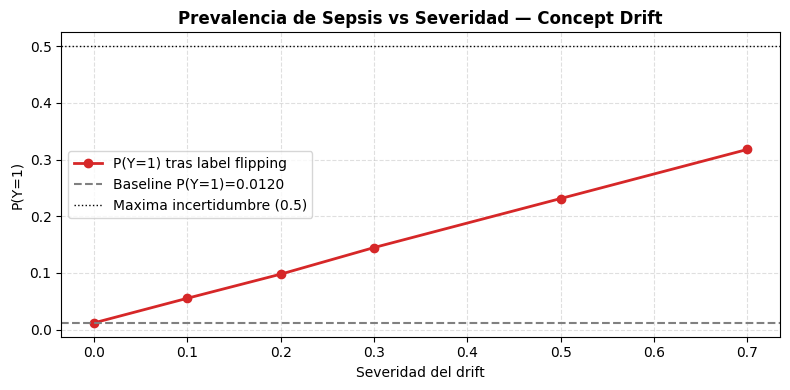

In [22]:
label_stats = []
for sev in SEVERITIES:
    if sev == 0.0:
        prev = float(df_target[LABEL_COL].mean())
        p_flip = 0.0
    else:
        df_d, _ = inj.transform(
            df_target,
            drift_severity=sev,
            label_col=LABEL_COL,
            drift_type="concept",
        )
        prev = float(df_d[LABEL_COL].mean())
        p_flip = 0.45 * sev
    label_stats.append(
        {
            "severidad": sev,
            "p_flip": round(p_flip, 4),
            "prevalencia_Y1": round(prev, 4),
        }
    )

df_label = pd.DataFrame(label_stats)
display(df_label)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    df_label["severidad"],
    df_label["prevalencia_Y1"],
    "o-",
    color="#d62728",
    lw=2,
    label="P(Y=1) tras label flipping",
)
ax.axhline(
    df_target[LABEL_COL].mean(),
    color="gray",
    linestyle="--",
    lw=1.5,
    label=f"Baseline P(Y=1)={df_target[LABEL_COL].mean():.4f}",
)
ax.axhline(0.5, color="black", linestyle=":", lw=1, label="Maxima incertidumbre (0.5)")
ax.set_xlabel("Severidad del drift")
ax.set_ylabel("P(Y=1)")
ax.set_title("Prevalencia de Sepsis vs Severidad — Concept Drift", fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 12. Tabla de metricas de drift — VITALS (severidad=0.7)

`DriftInjector.summary()` reporta KS, PSI, direccion y parametros Beta por variable.


In [23]:
df_cov7, meta_cov7 = inj.transform(
    df_target,
    drift_severity=0.7,
    numeric_drift_config=NUM_CFG,
    drift_type="covariate",
)

display(DriftInjector.summary(meta_cov7))

,type,drift_severity,direction,beta_orig,beta_target,ks_stat,ks_pval,psi
variable,,,,,,,,
HR,numeric,0.7,high,"(10.24, 31.14)","(5.00, 2.00)",0.660576,0.0,2.409402
SBP,numeric,0.7,low,"(12.45, 20.75)","(2.00, 5.00)",0.307909,0.0,1.294095
MAP,numeric,0.7,low,"(11.39, 39.83)","(2.00, 5.00)",0.228647,0.0,0.967052
Resp,numeric,0.7,high,"(9.39, 43.39)","(5.00, 2.00)",0.682033,0.0,6.395659
Temp,numeric,0.7,extreme,"(189.44, 153.77)","(0.50, 0.50)",0.340768,0.0,2.290669


## 13. Conclusiones

- **Covariate drift** — shift en HR, SBP, MAP, Resp, Temp: el AUC cae de forma
  aproximadamente monotona. El modelo ve distribuciones de entrada que no
  corresponden al entrenamiento, degradando la Etapa 2 (predictor).
- **Concept drift** — label flipping: el AUC converge hacia **0.5** porque
  la relacion $P(Y|X)$ aprendida ya no es valida. Afecta directamente a la
  Etapa 2 sin alterar $P(X)$.
- **Both** — la degradacion es la mas pronunciada por la acumulacion de ambos efectos.

Este experimento provee la evidencia empirica base para el framework **DARL**:
un sistema que diagnostica si la degradacion proviene de $P(X)$ o $P(Y|X)$
puede recomendar **que etapa del pipeline** actualizar selectivamente.
